# NLP  — Fundamentos

## ¿Qué es NLP?

Natural Language Processing (NLP) es la rama del ML que trabaja
con **texto en lenguaje natural** — el lenguaje que usan los humanos,
no los ordenadores.

El problema central es que los ordenadores solo entienden números.
Todo el NLP es, en esencia, la respuesta a una pregunta:

> **¿Cómo convertimos texto en números con los que un modelo pueda aprender?**

## Estructura del notebook

| Sección | Contenido |
|---|---|
| 1 | El texto como dato — preprocesamiento |
| 2 | Tokenización |
| 3 | Representaciones de texto (Bag of Words, TF-IDF) |
| 4 | Similitud entre textos |
| 5 | Clasificación de texto con ML clásico |
| 6 | Análisis de sentimiento |
| 7 | Extracción de información |
| 8 | Métricas de evaluación en NLP |

## Lo que NO cubre este notebook
- Redes neuronales para NLP (RNNs, Transformers, LLMs)
- Traducción automática
- Chatbots
- Fine-tuning de modelos preentrenados

Todo eso viene después. Aquí construimos los fundamentos.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from collections import Counter
import re
import string

# NLP
import nltk
from nltk.tokenize import word_tokenize, sent_tokenize
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer, WordNetLemmatizer
from nltk.util import ngrams

# ML
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.pipeline import Pipeline
from sklearn.decomposition import TruncatedSVD

plt.rcParams.update({
    'figure.dpi': 120, 'axes.spines.top': False,
    'axes.spines.right': False, 'grid.alpha': 0.3,
    'font.size': 11, 'axes.titlesize': 13,
    'axes.titleweight': 'bold',
})

# Descargar recursos NLTK necesarios
recursos = ['punkt', 'punkt_tab', 'stopwords',
            'wordnet', 'averaged_perceptron_tagger']
for r in recursos:
    nltk.download(r, quiet=True)

print("✅ Setup completado")

✅ Setup completado


# 1️⃣ El texto como dato — ¿por qué es difícil?

El texto es el tipo de dato más desordenado que existe:

- **Variabilidad**: "bueno", "Bueno", "BUENO" son lo mismo para un humano
- **Ambigüedad**: "banco" puede ser mueble o institución financiera
- **Morfología**: "correr", "corro", "corriendo" comparten raíz
- **Longitud variable**: una reseña puede tener 3 palabras o 3000
- **Ruido**: erratas, abreviaciones, emojis, HTML

El preprocesamiento convierte texto crudo en texto limpio y normalizado
antes de aplicar cualquier representación numérica.

### Pipeline típico de preprocesamiento

```
Texto crudo
    ↓
Minúsculas
    ↓
Eliminar ruido (HTML, URLs, puntuación)
    ↓
Tokenización (dividir en unidades)
    ↓
Eliminar stopwords
    ↓
Stemming o Lemmatización
    ↓
Texto limpio → representación numérica
```

In [2]:
TEXT = """
    ¡¡Este producto es INCREÍBLE!! Lo compré hace 3 días y ya lo
    recomendé a todos mis amigos. La calidad es muy buena, aunque
    el precio podría ser mejor... ¿Vale la pena? ¡Totalmente! 😊
    Visita www.ejemplo.com para más info. #compras #recomendado
"""

print("=" * 55)
print("TEXTO ORIGINAL:")
print(TEXT)
print("=" * 55)

# --- Paso 1: minúsculas ---
paso1 = TEXT.lower()
print(f"\nPaso 1 — Minúsculas:\n{paso1[:80]}...")

# --- Paso 2: eliminar URLs ---
paso2 = re.sub(r'http\S+|www\S+', '', paso1)
print(f"\nPaso 2 — Sin URLs:\n{paso2[:80]}...")

# --- Paso 3: eliminar menciones y hashtags ---
paso3 = re.sub(r'@\w+|#\w+', '', paso2)
print(f"\nPaso 3 — Sin hashtags:\n{paso3[:80]}...")

# --- Paso 4: eliminar puntuación y caracteres especiales ---
paso4 = re.sub(r'[^\w\s]', ' ', paso3)   # conserva letras y espacios
paso4 = re.sub(r'\d+', ' ', paso4)        # elimina números
paso4 = re.sub(r'\s+', ' ', paso4).strip()
print(f"\nPaso 4 — Sin puntuación:\n{paso4}")

# --- Paso 5: tokenizar ---
tokens = word_tokenize(paso4)
print(f"\nPaso 5 — Tokens ({len(tokens)}):\n{tokens}")

# --- Paso 6: eliminar stopwords ---
stop_es = set(['el', 'la', 'los', 'las', 'un', 'una', 'de', 'del',
               'que', 'y', 'en', 'a', 'es', 'se', 'lo', 'le', 'me',
               'mi', 'su', 'ya', 'por', 'con', 'al', 'para', 'como',
               'pero', 'más', 'muy', 'todo', 'todos', 'aunque', 'o'])
tokens_limpios = [t for t in tokens if t not in stop_es and len(t) > 2]
print(f"\nPaso 6 — Sin stopwords ({len(tokens_limpios)}):\n{tokens_limpios}")

TEXTO ORIGINAL:

    ¡¡Este producto es INCREÍBLE!! Lo compré hace 3 días y ya lo
    recomendé a todos mis amigos. La calidad es muy buena, aunque
    el precio podría ser mejor... ¿Vale la pena? ¡Totalmente! 😊
    Visita www.ejemplo.com para más info. #compras #recomendado


Paso 1 — Minúsculas:

    ¡¡este producto es increíble!! lo compré hace 3 días y ya lo
    recomendé ...

Paso 2 — Sin URLs:

    ¡¡este producto es increíble!! lo compré hace 3 días y ya lo
    recomendé ...

Paso 3 — Sin hashtags:

    ¡¡este producto es increíble!! lo compré hace 3 días y ya lo
    recomendé ...

Paso 4 — Sin puntuación:
este producto es increíble lo compré hace días y ya lo recomendé a todos mis amigos la calidad es muy buena aunque el precio podría ser mejor vale la pena totalmente visita para más info

Paso 5 — Tokens (35):
['este', 'producto', 'es', 'increíble', 'lo', 'compré', 'hace', 'días', 'y', 'ya', 'lo', 'recomendé', 'a', 'todos', 'mis', 'amigos', 'la', 'calidad', 'es', 'muy', 'buena

## Stemming vs Lemmatización

Ambas técnicas reducen palabras a su forma base, pero de formas distintas:

| | Stemming | Lemmatización |
|---|---|---|
| **Método** | Corta sufijos con reglas | Usa diccionario morfológico |
| **Resultado** | Raíz aproximada (puede no ser palabra) | Forma base real (lema) |
| **Velocidad** | Rápido | Más lento |
| **Precisión** | Menor | Mayor |
| **Ejemplo** | "running" → "run" / "better" → "better" | "running" → "run" / "better" → "good" |

En inglés ambas funcionan bien. Para español hay opciones en SpaCy.

Palabra         Stem            Lema (verb)     Lema (noun)
------------------------------------------------------------
running         run             run             running
runs            run             run             run
ran             ran             run             ran
easily          easili          easily          easily
fairly          fairli          fairly          fairly
studies         studi           study           study
studying        studi           study           studying
studied         studi           study           studied
better          better          better          better
caring          care            care            caring


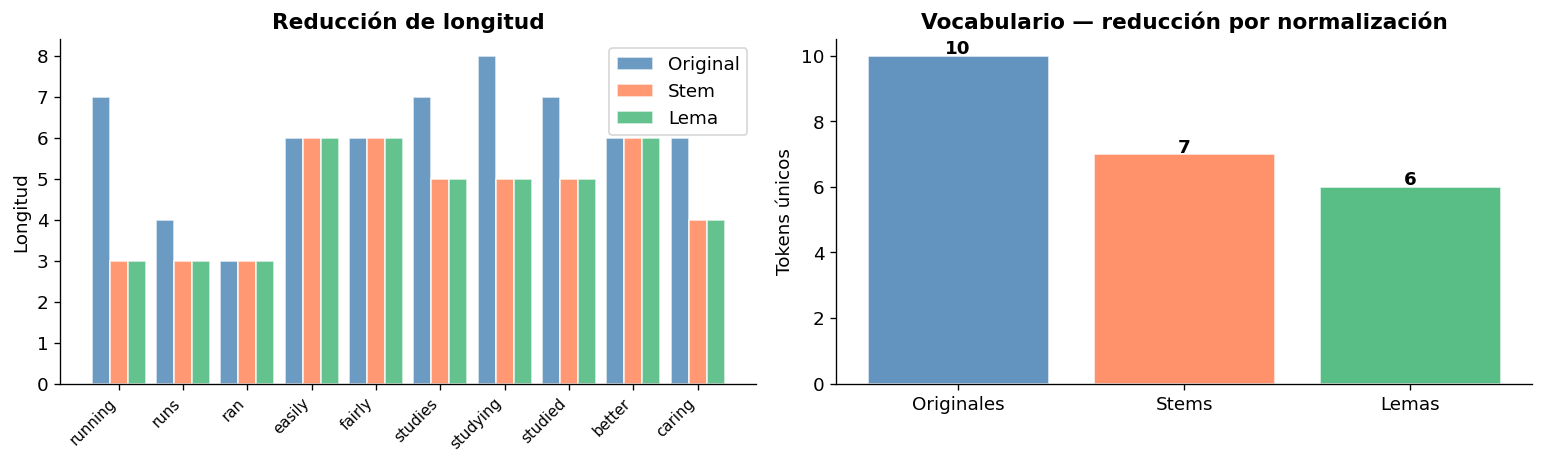

In [5]:
stemmer = PorterStemmer()
lemmatizer = WordNetLemmatizer()

palabras = ['running', 'runs', 'ran', 'easily', 'fairly',
            'studies', 'studying', 'studied', 'better', 'caring']

print(f"{'Palabra':<15} {'Stem':<15} {'Lema (verb)':<15} {'Lema (noun)'}")
print("-" * 60)
for p in palabras:
    stem  = stemmer.stem(p)
    lema_v = lemmatizer.lemmatize(p, pos='v')
    lema_n = lemmatizer.lemmatize(p, pos='n')
    print(f"{p:<15} {stem:<15} {lema_v:<15} {lema_n}")

# Visualización del efecto
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

stems = [stemmer.stem(p) for p in palabras]
lemas = [lemmatizer.lemmatize(p, pos='v') for p in palabras]

# Longitud original vs stem vs lema
orig_len = [len(p) for p in palabras]
stem_len = [len(s) for s in stems]
lema_len = [len(l) for l in lemas]

x = np.arange(len(palabras))
w = 0.28
ax = axes[0]
ax.bar(x-w, orig_len, w, label='Original', color='steelblue',  alpha=0.8, edgecolor='white')
ax.bar(x,   stem_len, w, label='Stem',     color='coral',      alpha=0.8, edgecolor='white')
ax.bar(x+w, lema_len, w, label='Lema',     color='mediumseagreen', alpha=0.8, edgecolor='white')
ax.set_xticks(x); ax.set_xticklabels(palabras, rotation=45, ha='right', fontsize=9)
ax.set_ylabel('Longitud'); ax.set_title('Reducción de longitud')
ax.legend()

# Unique tokens producidos
ax = axes[1]
n_orig  = len(set(palabras))
n_stems = len(set(stems))
n_lemas = len(set(lemas))
cats = ['Originales', 'Stems', 'Lemas']
vals = [n_orig, n_stems, n_lemas]
colors = ['steelblue', 'coral', 'mediumseagreen']
bars  = ax.bar(cats, vals, color=colors, edgecolor='white', alpha=0.85)
for bar, v in zip(bars, vals):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.05,
            str(v), ha='center', fontweight='bold')
ax.set_ylabel('Tokens únicos')
ax.set_title('Vocabulario — reducción por normalización')

plt.tight_layout()
plt.show()


 2️⃣ Tokenización — dividir texto en unidades

La tokenización es el primer paso de cualquier pipeline NLP.
Define qué es la unidad mínima de procesamiento.

### Tipos de tokenización

| Tipo | Unidad | Cuándo usar |
|---|---|---|
| Por palabras | "hola mundo" → ["hola", "mundo"] | NLP clásico |
| Por caracteres | "hola" → ["h","o","l","a"] | Modelos de lenguaje de carácter |
| Por subpalabras | BPE, WordPiece | LLMs (BERT, GPT) |
| Por oraciones | Párrafo → lista de oraciones | Resumen, análisis de discurso |
| N-gramas | Secuencias de N tokens | Modelos de lenguaje estadísticos |
"""


TOKENIZACIÓN POR PALABRAS:
  ['El', 'machine', 'learning', 'es', 'una', 'rama', 'de', 'la', 'inteligencia', 'artificial', '.', 'Los', 'modelos', 'aprenden', 'de', 'los', 'datos', '.', 'La', 'regresión', 'lineal', 'es', 'el', 'algoritmo', 'más', 'simple', 'pero', 'muy', 'poderoso', '.']
  Total: 30 tokens

TOKENIZACIÓN POR ORACIONES:
  [1] El machine learning es una rama de la inteligencia artificial.
  [2] Los modelos aprenden de los datos.
  [3] La regresión lineal es el
algoritmo más simple pero muy poderoso.

TOKENIZACIÓN POR CARACTERES:
  ['E', 'l', ' ', 'm', 'a', 'c', 'h', 'i', 'n', 'e', ' ', 'l', 'e', 'a', 'r', 'n', 'i', 'n', 'g', ' ', 'e', 's', ' ', 'u', 'n', 'a', ' ', 'r', 'a', 'm']

N-GRAMAS:
  2-gramas: [('machine', 'learning'), ('learning', 'una'), ('una', 'rama'), ('rama', 'inteligencia'), ('inteligencia', 'artificial')]
  3-gramas: [('machine', 'learning', 'una'), ('learning', 'una', 'rama'), ('una', 'rama', 'inteligencia'), ('rama', 'inteligencia', 'artificial'), ('inteli

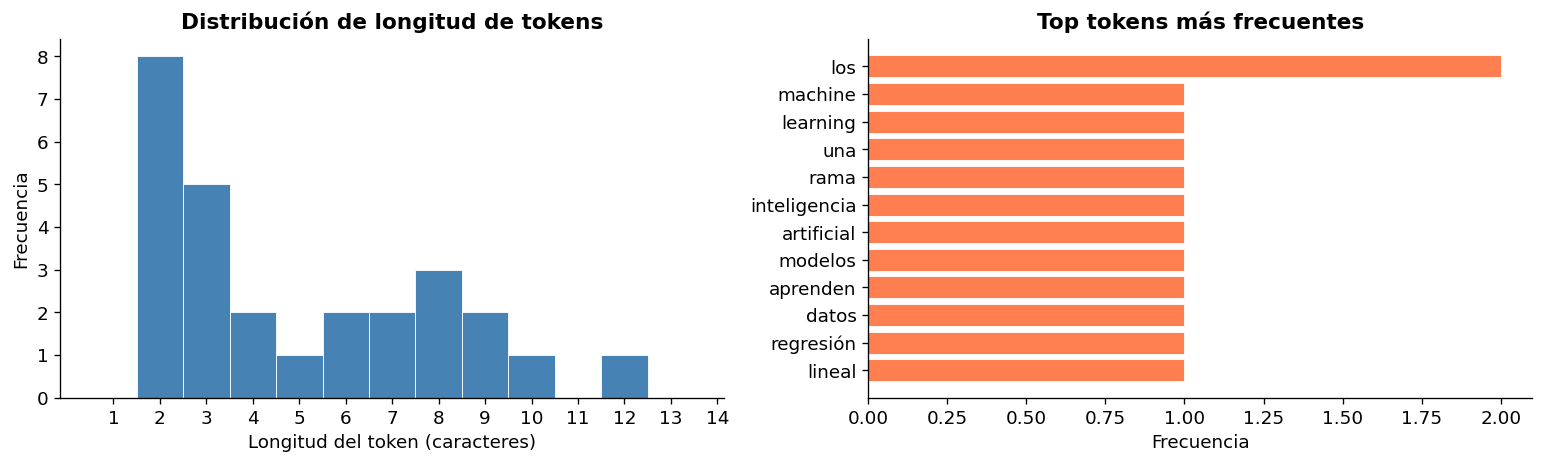

In [6]:
tokenized_text = """
El machine learning es una rama de la inteligencia artificial.
Los modelos aprenden de los datos. La regresión lineal es el
algoritmo más simple pero muy poderoso.
"""

print("TOKENIZACIÓN POR PALABRAS:")
tokens_palabras = word_tokenize(tokenized_text)
print(f"  {tokens_palabras}\n  Total: {len(tokens_palabras)} tokens")

print("\nTOKENIZACIÓN POR ORACIONES:")
oraciones = sent_tokenize(tokenized_text)
for i, o in enumerate(oraciones):
    print(f"  [{i+1}] {o.strip()}")

print("\nTOKENIZACIÓN POR CARACTERES:")
chars = list(tokenized_text.strip()[:30])
print(f"  {chars}")

print("\nN-GRAMAS:")
tokens_limpios_tok = [t.lower() for t in tokens_palabras
                      if t.isalpha() and len(t) > 2]
for n in [2, 3]:
    ngs = list(ngrams(tokens_limpios_tok, n))[:5]
    print(f"  {n}-gramas: {ngs}")

# Visualizar distribución de longitud de tokens
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

longitudes = [len(t) for t in tokens_palabras if t.isalpha()]
axes[0].hist(longitudes, bins=range(1, 15), color='steelblue',
             edgecolor='white', linewidth=0.5, align='left')
axes[0].set_xlabel('Longitud del token (caracteres)')
axes[0].set_ylabel('Frecuencia')
axes[0].set_title('Distribución de longitud de tokens')
axes[0].set_xticks(range(1, 15))

# Frecuencia de tokens
freq = Counter([t.lower() for t in tokens_palabras if t.isalpha() and len(t) > 2])
top_tokens = freq.most_common(12)
nombres, conteos = zip(*top_tokens)
axes[1].barh(list(nombres)[::-1], list(conteos)[::-1],
             color='coral', edgecolor='white', linewidth=0.5)
axes[1].set_xlabel('Frecuencia')
axes[1].set_title('Top tokens más frecuentes')

plt.tight_layout()
plt.show()

# 3️⃣ Representaciones numéricas de texto

El gran reto: pasar de palabras a números que preserven significado.

### Evolución histórica

```
Texto crudo
    ↓
One-Hot Encoding          ← cada palabra es un vector con un 1
    ↓
Bag of Words (BoW)        ← contar ocurrencias de palabras
    ↓
TF-IDF                    ← BoW ponderado por rareza de la palabra
    ↓
Word Embeddings           ← word2vec, GloVe (siguiente nivel)
    ↓
Contextual Embeddings     ← BERT, GPT (sección avanzada)
```



In [7]:
print("=" * 50)
print("ONE-HOT ENCODING")
print("=" * 50)

corpus_mini = ["el gato come pescado", "el perro come carne",
               "el gato juega"]
vocabulario = sorted(set(" ".join(corpus_mini).split()))
vocab_idx  = {w: i for i, w in enumerate(vocabulario)}

print(f"\nVocabulario ({len(vocabulario)} palabras): {vocabulario}")

print("\nMatriz One-Hot:")
print(f"{'':15}", end="")
for w in vocabulario:
    print(f"{w:>8}", end="")
print()

for doc in corpus_mini:
    vec = np.zeros(len(vocabulario), dtype=int)
    for word in doc.split():
        vec[vocab_idx[word]] = 1
    print(f"{doc[:14]:<15}", end="")
    for v in vec:
        print(f"{v:>8}", end="")
    print()

print("\n⚠️  Problema del One-Hot:")
print(" - Vectores dispersos (la mayoría son 0)")
print(" - No captura frecuencia ni importancia")
print(" - No captura relación semántica entre palabras")
print(" - Dimensión = tamaño del vocabulario (puede ser >100.000)")

ONE-HOT ENCODING

Vocabulario (7 palabras): ['carne', 'come', 'el', 'gato', 'juega', 'perro', 'pescado']

Matriz One-Hot:
                  carne    come      el    gato   juega   perro pescado
el gato come p        0       1       1       1       0       0       1
el perro come         1       1       1       0       0       1       0
el gato juega         0       0       1       1       1       0       0

⚠️  Problema del One-Hot:
 - Vectores dispersos (la mayoría son 0)
 - No captura frecuencia ni importancia
 - No captura relación semántica entre palabras
 - Dimensión = tamaño del vocabulario (puede ser >100.000)


## Bag of Words (BoW)

En lugar de 0/1, contamos cuántas veces aparece cada palabra.
El documento se convierte en un "saco de palabras" — perdemos
el orden pero ganamos información de frecuencia.

```
"el gato come pescado el día"
         ↓
{el:2, gato:1, come:1, pescado:1, día:1}
         ↓
Vector: [2, 1, 1, 1, 1, 0, 0, ...]
```

In [9]:
corpus = [
    "este producto es excelente muy bueno",
    "calidad muy buena precio justo recomendado",
    "producto malo no funciona mal calidad",
    "terrible no recomendado muy malo",
    "buena calidad excelente precio muy bueno",
    "no funciona mal producto devuelto",
    "increíble producto excelente muy recomendado",
    "pésimo producto terrible no sirve",
]
etiquetas = [1, 1, 0, 0, 1, 0, 1, 0]  # 1=positivo, 0=negativo

# Crear BoW con sklearn
vectorizer_bow = CountVectorizer()
X_bow = vectorizer_bow.fit_transform(corpus)
vocab_bow = vectorizer_bow.get_feature_names_out()

print("BAG OF WORDS")
print(f"Shape de la matriz: {X_bow.shape}  → ({len(corpus)} docs, {len(vocab_bow)} palabras)")
print(f"\nVocabulario: {list(vocab_bow)}")

# Mostrar matriz como array denso
X_dense = X_bow.toarray()
print("\nMatriz BoW (filas=docs, cols=palabras):")
header = f"{'Doc':>5} | " + " ".join(f"{w:>6}" for w in vocab_bow)
print(header)
print("-" * len(header))
for i, (fila, et) in enumerate(zip(X_dense, etiquetas)):
    label = "+(pos)" if et == 1 else "-(neg)"
    row = f"  D{i+1} | " + " ".join(f"{v:>6}" for v in fila)
    print(f"{row}  {label}")



BAG OF WORDS
Shape de la matriz: (8, 20)  → (8 docs, 20 palabras)

Vocabulario: ['buena', 'bueno', 'calidad', 'devuelto', 'es', 'este', 'excelente', 'funciona', 'increíble', 'justo', 'mal', 'malo', 'muy', 'no', 'precio', 'producto', 'pésimo', 'recomendado', 'sirve', 'terrible']

Matriz BoW (filas=docs, cols=palabras):
  Doc |  buena  bueno calidad devuelto     es   este excelente funciona increíble  justo    mal   malo    muy     no precio producto pésimo recomendado  sirve terrible
-----------------------------------------------------------------------------------------------------------------------------------------------------------------------
  D1 |      0      1      0      0      1      1      1      0      0      0      0      0      1      0      0      1      0      0      0      0  +(pos)
  D2 |      1      0      1      0      0      0      0      0      0      1      0      0      1      0      1      0      0      1      0      0  +(pos)
  D3 |      0      0      1      0

## TF-IDF — Term Frequency × Inverse Document Frequency

El modelo **Bag of Words (BoW)** asigna el mismo peso a todas las palabras, independientemente de su importancia.  
Por ejemplo: palabras como "el", "de", "la" aparecen en casi todos los documentos y aportan muy poca información discriminativa, mientras que palabras como "excelente", "defectuoso" o "recomendado" suelen ser mucho más informativas.

**TF-IDF** soluciona esto ponderando cada palabra según su **rareza** en el corpus completo.

### Fórmulas clave

$$
\text{TF}(t, d) = \frac{\text{número de veces que aparece } t \text{ en el documento } d}{\text{total de términos en el documento } d}
$$

$$
\text{IDF}(t) = \log\left( \frac{N}{1 + \text{df}(t)} \right)
$$

$$
\text{TF-IDF}(t, d) = \text{TF}(t, d) \times \text{IDF}(t)
$$

Donde:

- $t$ → término (palabra)  
- $d$ → documento  
- $N$ → número total de documentos en el corpus  
- $\text{df}(t)$ → número de documentos que contienen el término $t$ (document frequency)

### Interpretación práctica

- Palabras muy comunes (stopwords como "el", "y", "de") → tienen **IDF muy bajo** → peso casi nulo en TF-IDF  
- Palabras raras pero relevantes (que aparecen en pocos documentos) → **IDF alto** → gran peso cuando aparecen  
- Palabras frecuentes en un documento pero raras en el corpus → obtienen los **pesos más altos**

**Resultado final**:  
TF-IDF resalta las palabras que son **discriminativas** para diferenciar documentos, reduciendo drásticamente la influencia de términos genéricos.

(En la práctica, scikit-learn aplica algunas variantes menores, como sumar 1 al denominador de IDF o usar log base 10 en algunos casos, pero la idea central es exactamente esta.)

TF-IDF
Shape: (8, 20)

IDF por término (mayor = más raro = más informativo):
  devuelto     IDF=2.504  ████████████
  es           IDF=2.504  ████████████
  este         IDF=2.504  ████████████
  increíble    IDF=2.504  ████████████
  justo        IDF=2.504  ████████████
  pésimo       IDF=2.504  ████████████
  sirve        IDF=2.504  ████████████
  buena        IDF=2.099  ██████████
  bueno        IDF=2.099  ██████████
  funciona     IDF=2.099  ██████████
  mal          IDF=2.099  ██████████
  malo         IDF=2.099  ██████████
  precio       IDF=2.099  ██████████
  terrible     IDF=2.099  ██████████
  calidad      IDF=1.811  █████████
  excelente    IDF=1.811  █████████
  recomendado  IDF=1.811  █████████
  no           IDF=1.588  ███████
  muy          IDF=1.405  ███████
  producto     IDF=1.405  ███████


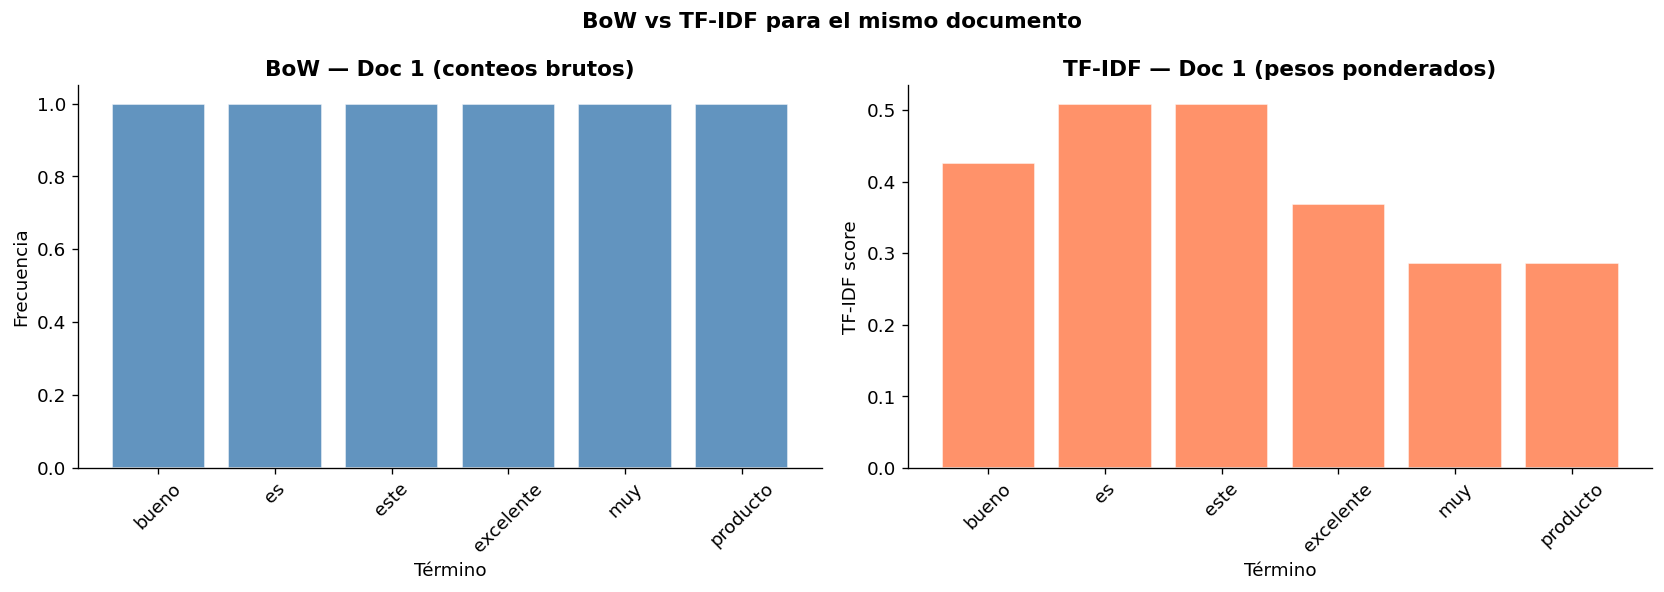

In [10]:
vectorizer_tfidf = TfidfVectorizer()
X_tfidf = vectorizer_tfidf.fit_transform(corpus)
vocab_tfidf = vectorizer_tfidf.get_feature_names_out()
X_tfidf_dense = X_tfidf.toarray()

print("TF-IDF")
print(f"Shape: {X_tfidf.shape}")

# IDF de cada término
idf_vals = vectorizer_tfidf.idf_
print("\nIDF por término (mayor = más raro = más informativo):")
idf_sorted = sorted(zip(vocab_tfidf, idf_vals), key=lambda x: x[1], reverse=True)
for term, idf in idf_sorted:
    bar = "█" * int(idf * 5)
    print(f"  {term:<12} IDF={idf:.3f}  {bar}")

# Comparativa BoW vs TF-IDF para un documento
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# BoW del doc 0
ax = axes[0]
bow_vals  = X_dense[0]
nonzero   = bow_vals > 0
ax.bar(np.array(vocab_bow)[nonzero], bow_vals[nonzero],
       color='steelblue', edgecolor='white', alpha=0.85)
ax.set_title('BoW — Doc 1 (conteos brutos)')
ax.set_xlabel('Término'); ax.set_ylabel('Frecuencia')
ax.tick_params(axis='x', rotation=45)

# TF-IDF del doc 0
ax = axes[1]
tfidf_vals = X_tfidf_dense[0]
nonzero_t  = tfidf_vals > 0
ax.bar(np.array(vocab_tfidf)[nonzero_t], tfidf_vals[nonzero_t],
       color='coral', edgecolor='white', alpha=0.85)
ax.set_title('TF-IDF — Doc 1 (pesos ponderados)')
ax.set_xlabel('Término'); ax.set_ylabel('TF-IDF score')
ax.tick_params(axis='x', rotation=45)

plt.suptitle('BoW vs TF-IDF para el mismo documento', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# 4️⃣ Similitud entre textos

Una vez que tenemos los textos convertidos en **vectores** (ya sea con Bag of Words, TF-IDF o embeddings), el siguiente paso es medir **qué tan parecidos son dos textos**.

### Similitud coseno (la más usada en NLP)

La **similitud coseno** mide el **ángulo** entre dos vectores, ignorando completamente su magnitud (es decir, la longitud del documento no afecta el resultado).

Fórmula:

$$
\cos(\theta) = \frac{A \cdot B}{\|A\| \cdot \|B\|}
$$

Donde:
- $A \cdot B$ → producto punto (dot product) entre los vectores  
- $\|A\|$ → norma (longitud) del vector A → $\sqrt{\sum a_i^2}$  
- $\|B\|$ → norma del vector B

### Interpretación de los valores

| Valor de cos(θ) | Significado                                      | Ejemplo práctico                              |
|-----------------|--------------------------------------------------|-----------------------------------------------|
| **1.0**         | Documentos idénticos (mismo contenido y dirección) | Mismo texto repetido                          |
| **0.0**         | Ninguna palabra en común (ángulo recto de 90°)   | Temas completamente diferentes                |
| **-1.0**        | Textos opuestos (solo posible con embeddings)    | "Me encanta" vs "Lo odio profundamente"       |
| Entre 0.7–0.99  | Muy similares                                    | Artículos sobre el mismo tema con distintas palabras |
| Entre 0.3–0.6   | Similitud moderada                               | Textos relacionados pero no idénticos         |
| < 0.2           | Poco o nada relacionados                         | Temas distintos                               |

### ¿Por qué usamos similitud coseno y no distancia euclidiana?

La **distancia euclidiana** se ve muy afectada por la longitud de los documentos:

- Un documento de 1000 palabras y otro de 10 palabras pueden tener **exactamente el mismo contenido proporcional**, pero sus vectores tendrán magnitudes muy diferentes → la distancia euclidiana será grande aunque el contenido sea casi idéntico.

La **similitud coseno**, en cambio:

- Ignora la magnitud (longitud del documento)  
- Solo mira la **dirección** (proporción de palabras)  
- Es mucho más robusta para comparar textos de diferente longitud

Por eso es el estándar en búsqueda de similitud, recomendadores, clustering de textos, detección de plagio, etc. cuando se usan representaciones como BoW o TF-IDF.

(Con embeddings densos como word2vec, BERT, etc., también puede dar valores negativos, lo que permite detectar oposición semántica — algo que no ocurre con conteos/TF-IDF.)



MATRIZ DE SIMILITUD COSENO:
                                Doc0  Doc1  Doc2  Doc3
Doc0 el machine learning es gua   1.00  0.26  0.14  0.51
Doc1 el aprendizaje automático    0.26  1.00  0.13  0.14
Doc2 me gusta el fútbol y el de   0.14  0.13  1.00  0.40
Doc3 el machine learning y el d   0.51  0.14  0.40  1.00


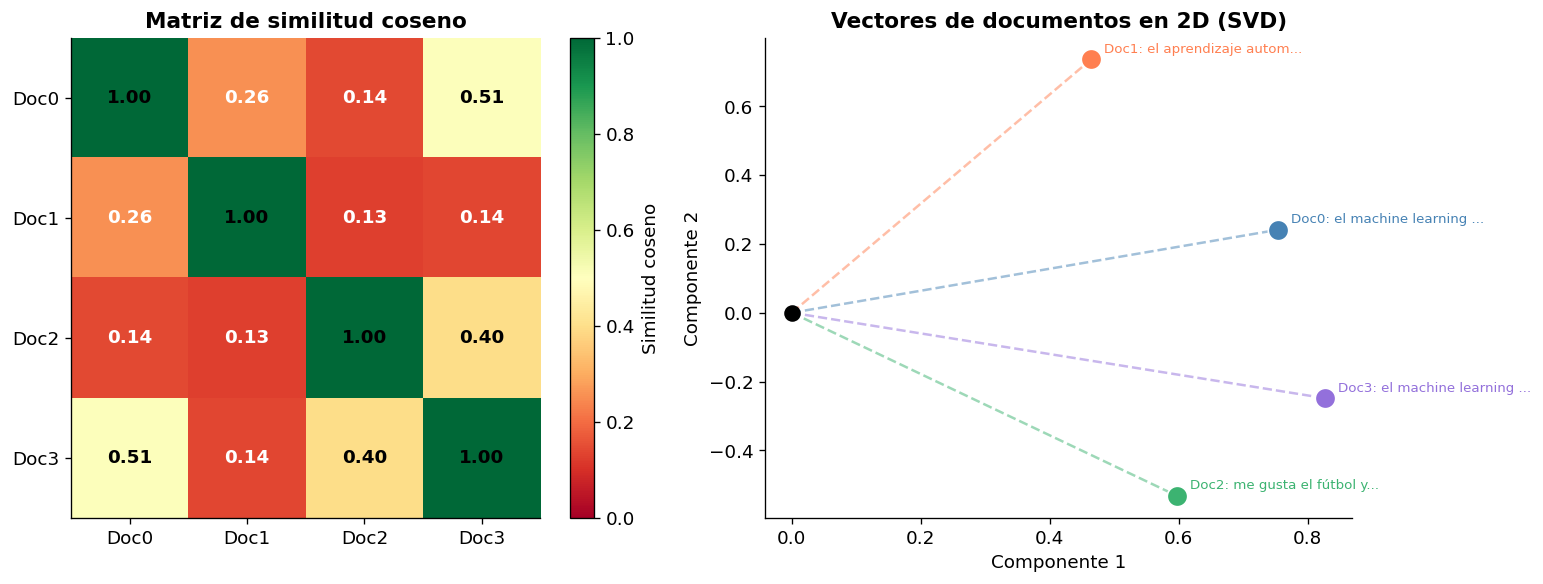

In [12]:
docs_sim = [
    "el machine learning es guay",        # 0
    "el aprendizaje automático es increíble",   # 1 — similar a 0
    "me gusta el fútbol y el deporte",          # 2 — diferente
    "el machine learning y el deporte combinan",# 3 — mezcla
]

vec_sim  = TfidfVectorizer()
X_sim    = vec_sim.fit_transform(docs_sim).toarray()
sim_mat  = cosine_similarity(X_sim)

print("MATRIZ DE SIMILITUD COSENO:")
print(f"{'':30}", end="")
for i in range(len(docs_sim)):
    print(f"  Doc{i}", end="")
print()
for i, doc in enumerate(docs_sim):
    print(f"Doc{i} {doc[:26]:<26} ", end="")
    for j in range(len(docs_sim)):
        print(f"  {sim_mat[i,j]:.2f}", end="")
    print()

# Heatmap
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
im = ax.imshow(sim_mat, cmap='RdYlGn', vmin=0, vmax=1, aspect='auto')
plt.colorbar(im, ax=ax, label='Similitud coseno')
labels_short = [f'Doc{i}' for i in range(len(docs_sim))]
ax.set_xticks(range(len(docs_sim))); ax.set_xticklabels(labels_short)
ax.set_yticks(range(len(docs_sim))); ax.set_yticklabels(labels_short)
ax.set_title('Matriz de similitud coseno')
for i in range(len(docs_sim)):
    for j in range(len(docs_sim)):
        ax.text(j, i, f'{sim_mat[i,j]:.2f}', ha='center', va='center',
                fontsize=11, fontweight='bold',
                color='white' if sim_mat[i,j] < 0.3 else 'black')

# Visualización de vectores en 2D (SVD para reducir dimensión)
ax = axes[1]
svd = TruncatedSVD(n_components=2, random_state=42)
X_2d = svd.fit_transform(X_sim)
colors_sim = ['steelblue', 'coral', 'mediumseagreen', 'mediumpurple']
for i, (punto, doc, color) in enumerate(zip(X_2d, docs_sim, colors_sim)):
    ax.scatter(*punto, color=color, s=150, zorder=3,
               edgecolors='white', linewidths=1)
    ax.annotate(f'Doc{i}: {doc[:20]}...', xy=punto,
                xytext=(punto[0]+0.02, punto[1]+0.02),
                fontsize=8, color=color)
    ax.plot([0, punto[0]], [0, punto[1]], color=color,
            lw=1.5, linestyle='--', alpha=0.5)
ax.scatter(0, 0, color='black', s=80, zorder=4)
ax.set_title('Vectores de documentos en 2D (SVD)')
ax.set_xlabel('Componente 1'); ax.set_ylabel('Componente 2')

plt.tight_layout()
plt.show()

# 5️⃣ Clasificación de texto con ML clásico

Ahora que sabemos representar texto como vectores, podemos
aplicar cualquier algoritmo de clasificación de ML.

### Dataset: análisis de reseñas

Usaremos un dataset más completo de reseñas de productos
con etiquetas positivo/negativo.

### Los 3 algoritmos más usados en NLP clásico

| Algoritmo | Por qué funciona bien en texto |
|---|---|
| **Naive Bayes** | Asume independencia de palabras (válida en BoW), muy rápido, funciona con poco datos |
| **Regresión Logística** | Aprende pesos por palabra, interpretable, muy sólido |
| **Linear SVC** | Maximiza el margen, robusto en alta dimensionalidad (mucho vocabulario) |

In [13]:
reseñas_positivas = [
    "producto excelente muy recomendado calidad increíble",
    "buena calidad precio justo muy satisfecho compra perfecta",
    "llegó rápido bien embalado funciona perfecto cinco estrellas",
    "increíble producto superó expectativas lo recomiendo totalmente",
    "muy bueno calidad precio inmejorable volvería comprar",
    "excelente envío rápido producto tal cual descripción",
    "fantástico producto calidad premium precio asequible",
    "muy contento compra material resistente buen acabado",
    "producto genial funciona perfectamente muy recomendable",
    "buenísimo calidad superior precio muy competitivo satisfecho",
    "llegó antes plazo perfecto estado recomiendo vendedor",
    "increíble relación calidad precio superó expectativas",
    "producto top calidad excelente muy satisfecho compra",
    "genial funciona mejor esperado envío rapidísimo gracias",
    "muy buen producto calidad buena precio razonable recomiendo",
]

reseñas_negativas = [
    "producto terrible no funciona devuelto decepcionado",
    "mala calidad roto primera semana no recomiendo evitar",
    "llegó tarde mal embalado roto no sirve devolución",
    "pésimo producto no corresponde descripción estafa evitar",
    "muy malo calidad horrible precio excesivo no compren",
    "decepcionante no funciona contacté soporte sin respuesta",
    "fatal producto roto llegó mal calidad penosa",
    "no recomiendo calidad horrible dinero tirado basura",
    "terrible experiencia producto defectuoso devolución difícil",
    "malo muy malo calidad deplorable no vale precio",
    "estafa producto falso no corresponde foto descripción",
    "pésima compra roto semana calidad inexistente fraude",
    "horrible no sirve nada roto llegar mala calidad",
    "muy decepcionante producto falla constantemente no recomiendo",
    "malísimo calidad penosa precio abusivo nunca más",
]

corpus_full = reseñas_positivas + reseñas_negativas
y_full      = [1]*len(reseñas_positivas) + [0]*len(reseñas_negativas)

print(f"Dataset: {len(corpus_full)} reseñas")
print(f"  Positivas: {sum(y_full)}")
print(f"  Negativas: {len(y_full) - sum(y_full)}")

# Train/test split
X_tr, X_te, y_tr, y_te = train_test_split(
    corpus_full, y_full, test_size=0.25, random_state=42, stratify=y_full
)
print(f"\nTrain: {len(X_tr)} | Test: {len(X_te)}")



Dataset: 30 reseñas
  Positivas: 15
  Negativas: 15

Train: 22 | Test: 8


In [14]:
#Pipeline = encadena preprocesamiento + modelo
# La gran ventaja: fit/predict sobre texto crudo directamente

pipelines = {
    'Naive Bayes': Pipeline([
        ('tfidf', TfidfVectorizer(ngram_range=(1,2), min_df=1)),
        ('clf',   MultinomialNB(alpha=0.5)),
    ]),
    'Regresión Logística': Pipeline([
        ('tfidf', TfidfVectorizer(ngram_range=(1,2), min_df=1)),
        ('clf',   LogisticRegression(max_iter=1000, C=1.0)),
    ]),
    'Linear SVC': Pipeline([
        ('tfidf', TfidfVectorizer(ngram_range=(1,2), min_df=1)),
        ('clf',   LinearSVC(C=1.0, max_iter=2000)),
    ]),
}

resultados = {}
print("ENTRENAMIENTO Y EVALUACIÓN:")
print("=" * 55)

for nombre, pipeline in pipelines.items():
    pipeline.fit(X_tr, y_tr)
    y_pred  = pipeline.predict(X_te)

    # Cross-validation sobre train
    cv_scores = cross_val_score(pipeline, X_tr, y_tr, cv=5, scoring='f1')

    from sklearn.metrics import accuracy_score, f1_score
    acc = accuracy_score(y_te, y_pred)
    f1  = f1_score(y_te, y_pred)

    resultados[nombre] = {
        'pipeline': pipeline,
        'accuracy': acc,
        'f1' : f1,
        'cv_mean' : cv_scores.mean(),
        'cv_std' : cv_scores.std(),
        'y_pred' : y_pred,
    }

    print(f"\n{nombre}:")
    print(f"  Accuracy : {acc:.4f}")
    print(f"  F1-Score : {f1:.4f}")
    print(f"  CV F1    : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

print("\n" + "=" * 55)

ENTRENAMIENTO Y EVALUACIÓN:

Naive Bayes:
  Accuracy : 1.0000
  F1-Score : 1.0000
  CV F1    : 0.8933 ± 0.1373

Regresión Logística:
  Accuracy : 1.0000
  F1-Score : 1.0000
  CV F1    : 0.8933 ± 0.1373

Linear SVC:
  Accuracy : 1.0000
  F1-Score : 1.0000
  CV F1    : 0.8933 ± 0.1373



/tmp/ipykernel_373/2398993972.py:33: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([n.replace(' ','\n') for n in nombres], fontsize=9)


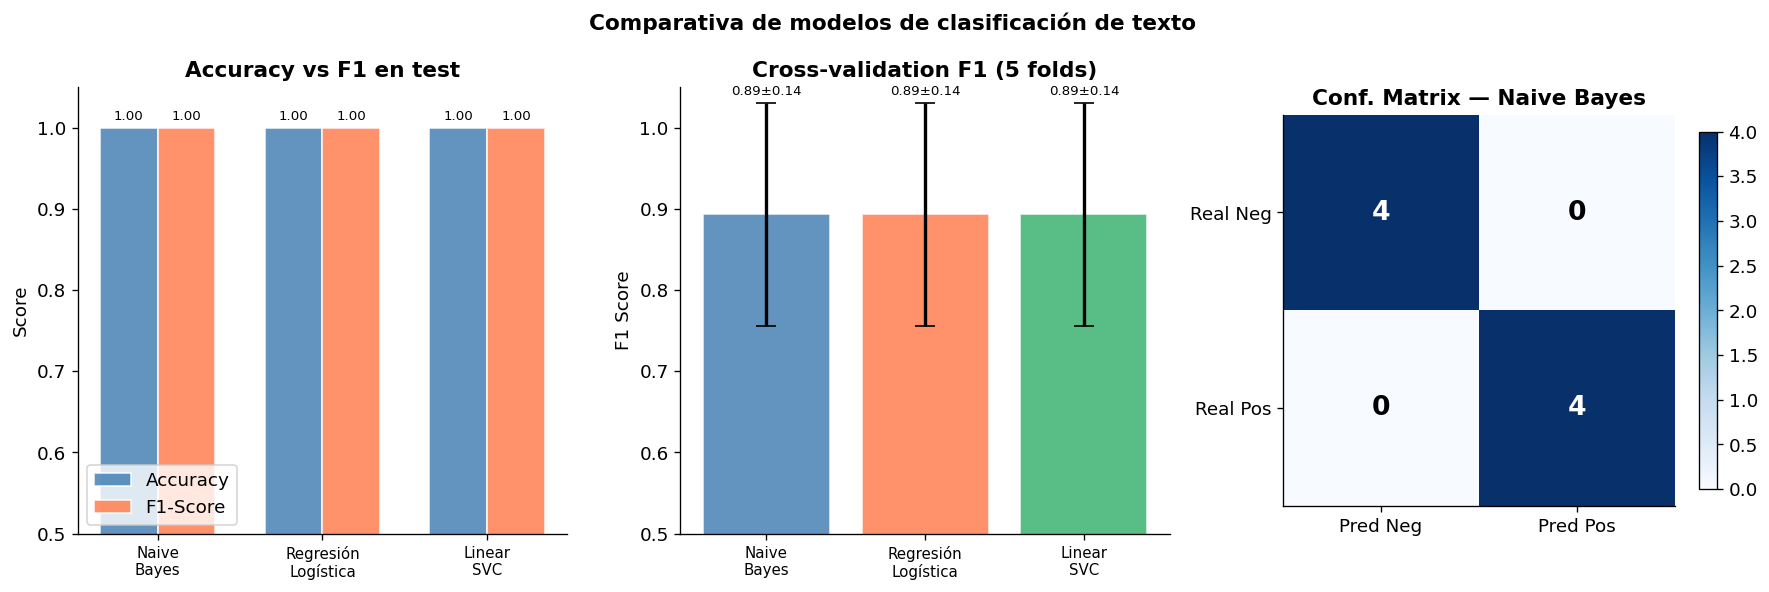


🏆 Mejor modelo: Naive Bayes (F1=1.0000)


In [15]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Comparativa de modelos de clasificación de texto',
             fontsize=13, fontweight='bold')

nombres   = list(resultados.keys())
accs      = [resultados[n]['accuracy'] for n in nombres]
f1s       = [resultados[n]['f1']       for n in nombres]
cv_means  = [resultados[n]['cv_mean']  for n in nombres]
cv_stds   = [resultados[n]['cv_std']   for n in nombres]
colores   = ['steelblue', 'coral', 'mediumseagreen']

# Accuracy vs F1
ax = axes[0]
x  = np.arange(len(nombres))
w  = 0.35
ax.bar(x-w/2, accs, w, label='Accuracy', color='steelblue', edgecolor='white', alpha=0.85)
ax.bar(x+w/2, f1s,  w, label='F1-Score', color='coral',     edgecolor='white', alpha=0.85)
ax.set_xticks(x); ax.set_xticklabels([n.replace(' ','\n') for n in nombres], fontsize=9)
ax.set_ylim(0.5, 1.05); ax.set_ylabel('Score')
ax.set_title('Accuracy vs F1 en test')
ax.legend()
for xi, a, f in zip(x, accs, f1s):
    ax.text(xi-w/2, a+0.01, f'{a:.2f}', ha='center', fontsize=8)
    ax.text(xi+w/2, f+0.01, f'{f:.2f}', ha='center', fontsize=8)

# CV scores con error bars
ax = axes[1]
bars = ax.bar(nombres, cv_means, color=colores, edgecolor='white', alpha=0.85,
              yerr=cv_stds, capsize=6,
              error_kw={'elinewidth':2, 'ecolor':'black'})
ax.set_ylim(0.5, 1.05); ax.set_ylabel('F1 Score')
ax.set_title('Cross-validation F1 (5 folds)')
ax.set_xticklabels([n.replace(' ','\n') for n in nombres], fontsize=9)
for bar, m, s in zip(bars, cv_means, cv_stds):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+s+0.01,
            f'{m:.2f}±{s:.2f}', ha='center', fontsize=8)

# Matriz de confusión del mejor modelo
mejor = max(resultados, key=lambda n: resultados[n]['f1'])
cm = confusion_matrix(y_te, resultados[mejor]['y_pred'])
ax = axes[2]
im = ax.imshow(cm, cmap='Blues')
plt.colorbar(im, ax=ax, shrink=0.8)
ax.set_xticks([0,1]); ax.set_yticks([0,1])
ax.set_xticklabels(['Pred Neg','Pred Pos'])
ax.set_yticklabels(['Real Neg','Real Pos'])
ax.set_title(f'Conf. Matrix — {mejor}')
for i in range(2):
    for j in range(2):
        ax.text(j, i, str(cm[i,j]), ha='center', va='center',
                fontsize=16, fontweight='bold',
                color='white' if cm[i,j] > cm.max()/2 else 'black')

plt.tight_layout()
plt.show()

print(f"\n🏆 Mejor modelo: {mejor} (F1={resultados[mejor]['f1']:.4f})")

## Palabras más importantes por clase

Una de las grandes ventajas de los modelos lineales en NLP
es la **interpretabilidad**: podemos ver qué palabras empuja
el modelo hacia cada clase.

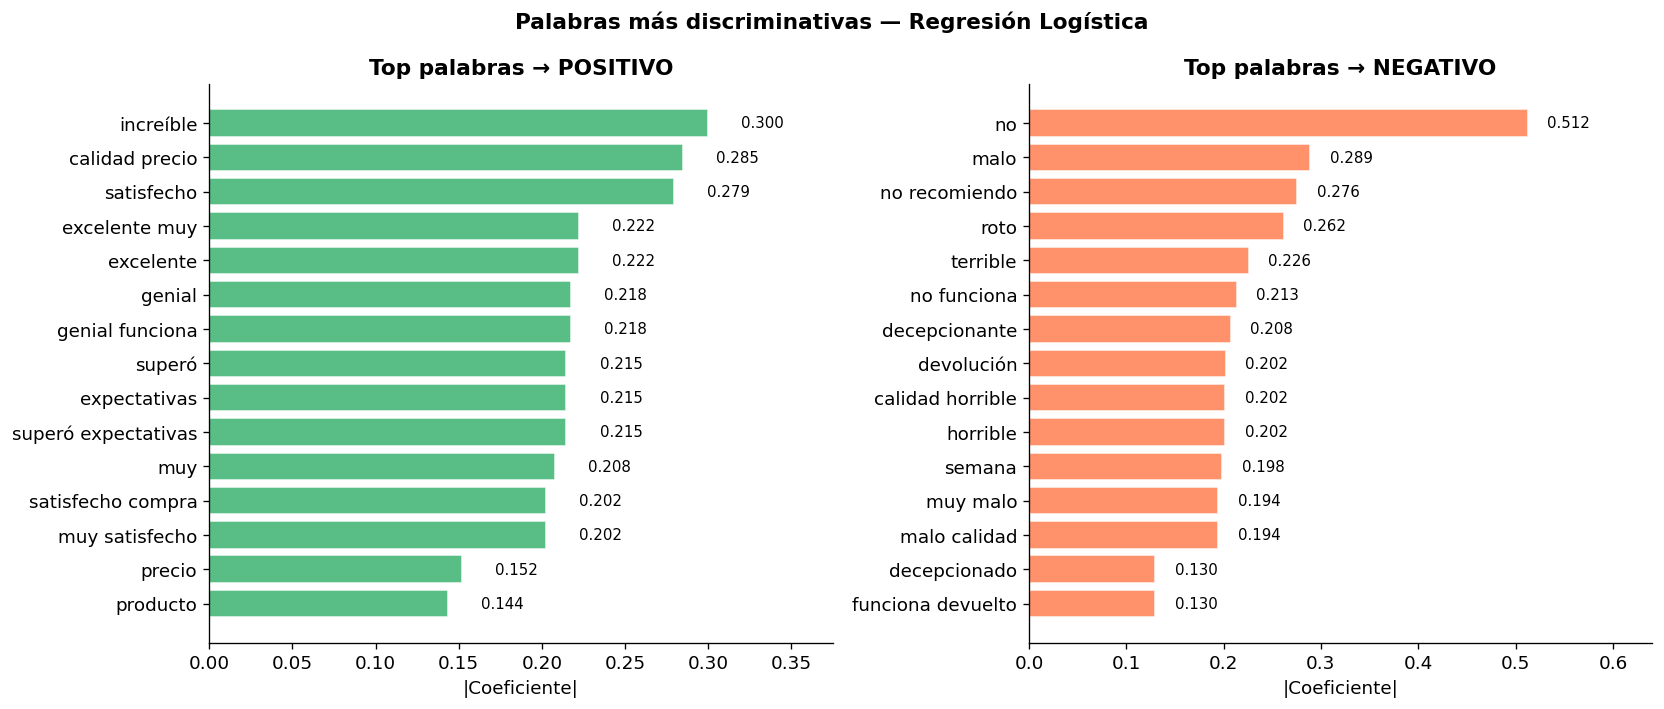

In [16]:

pipeline_lr  = resultados['Regresión Logística']['pipeline']
tfidf_fitted = pipeline_lr.named_steps['tfidf']
clf_fitted   = pipeline_lr.named_steps['clf']

vocab_fi     = np.array(tfidf_fitted.get_feature_names_out())
coefs        = clf_fitted.coef_[0]  # coeficiente por feature

# Top palabras positivas y negativas
n_top    = 15
top_pos  = np.argsort(coefs)[-n_top:][::-1]
top_neg  = np.argsort(coefs)[:n_top]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Palabras más discriminativas — Regresión Logística',
             fontsize=13, fontweight='bold')

for ax, indices, titulo, color in [
    (axes[0], top_pos, 'Top palabras → POSITIVO', 'mediumseagreen'),
    (axes[1], top_neg, 'Top palabras → NEGATIVO',  'coral'),
]:
    palabras_top = vocab_fi[indices]
    coefs_top    = coefs[indices]
    ax.barh(palabras_top[::-1], np.abs(coefs_top[::-1]),
            color=color, edgecolor='white', alpha=0.85)
    ax.set_xlabel('|Coeficiente|')
    ax.set_title(titulo)
    ax.set_xlim(0, np.abs(coefs_top).max() * 1.25)
    for i, (p, c) in enumerate(zip(palabras_top[::-1], np.abs(coefs_top[::-1]))):
        ax.text(c + 0.02, i, f'{c:.3f}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

# 6️⃣ Análisis de sentimiento

El análisis de sentimiento es la tarea NLP más usada en negocio:
determinar si un texto expresa una opinión positiva, negativa o neutra.

### Aproximaciones

| Nivel | Método | Ejemplo |
|---|---|---|
| **Léxico** | Diccionario de palabras con polaridad | VADER, SentiWordNet |
| **ML supervisado** | Clasificador entrenado en datos etiquetados | Lo que acabamos de hacer |
| **Aspectos** | Sentimiento por aspecto del producto | "batería mala, pantalla excelente" |

### VADER — léxico para textos informales

VADER (Valence Aware Dictionary and sEntiment Reasoner) es un
diccionario de sentimiento diseñado para redes sociales.
Maneja mayúsculas, signos de exclamación y emojis.

ANÁLISIS VADER:
Texto                                            neg    neu    pos   compound Sentimiento
------------------------------------------------------------------------------------------
This product is AMAZING!!! Best purchase eve   0.000  0.342  0.658      0.891  POSITIVO
Terrible quality, complete waste of money 😡    0.596  0.404  0.000     -0.710  NEGATIVO
It's okay, nothing special but works fine      0.176  0.431  0.393      0.255  POSITIVO
NOT bad at all! Surprisingly good for the pr   0.000  0.421  0.579      0.804  POSITIVO
Awful. Just awful. Don't buy this garbage.     0.545  0.455  0.000     -0.718  NEGATIVO
Pretty good! Could be better but I'm satisfi   0.000  0.222  0.778      0.918  POSITIVO


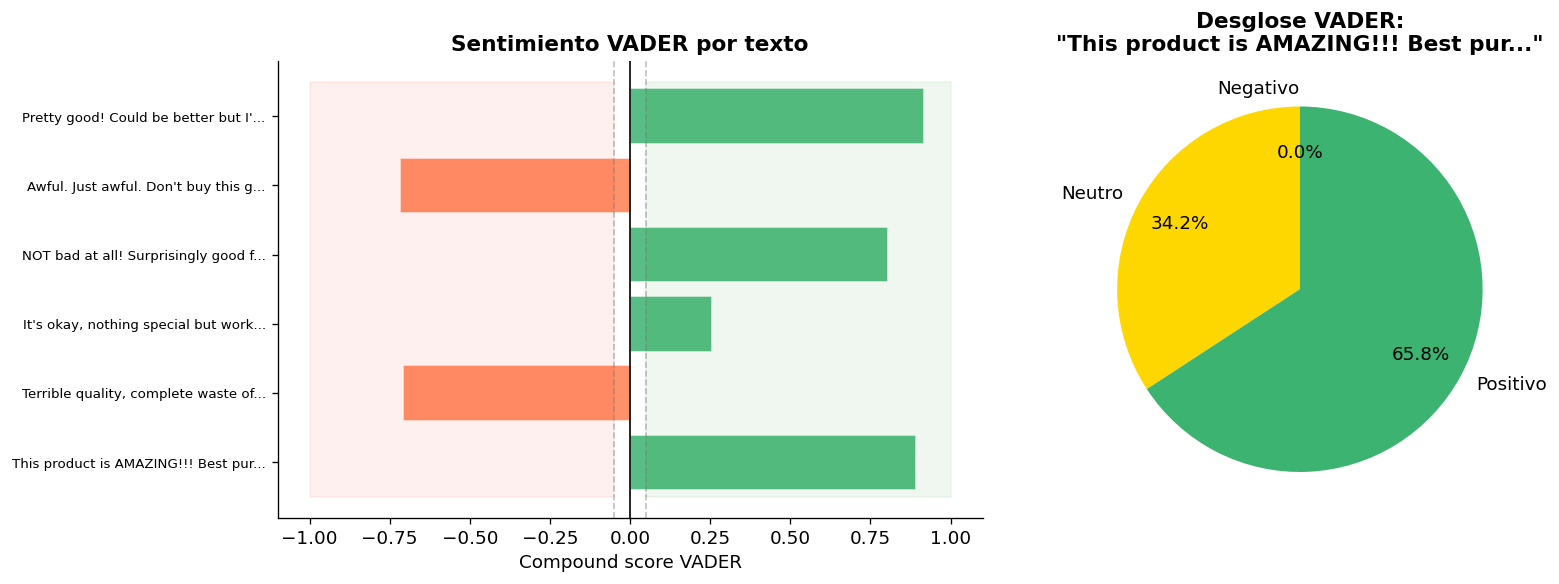

In [17]:
from nltk.sentiment.vader import SentimentIntensityAnalyzer
nltk.download('vader_lexicon', quiet=True)

sia = SentimentIntensityAnalyzer()

textos_vader = [
    "This product is AMAZING!!! Best purchase ever 😊",
    "Terrible quality, complete waste of money 😡",
    "It's okay, nothing special but works fine",
    "NOT bad at all! Surprisingly good for the price",
    "Awful. Just awful. Don't buy this garbage.",
    "Pretty good! Could be better but I'm satisfied :)",
]

print("ANÁLISIS VADER:")
print(f"{'Texto':<45} {'neg':>6} {'neu':>6} {'pos':>6} {'compound':>10} {'Sentimiento'}")
print("-" * 90)

resultados_vader = []
for texto in textos_vader:
    scores = sia.polarity_scores(texto)
    if scores['compound'] >= 0.05:
        sentiment = "POSITIVO"
    elif scores['compound'] <= -0.05:
        sentiment = "NEGATIVO"
    else:
        sentiment = "NEUTRO"
    resultados_vader.append((texto, scores, sentiment))
    print(f"{texto[:44]:<45} {scores['neg']:>6.3f} {scores['neu']:>6.3f} "
          f"{scores['pos']:>6.3f} {scores['compound']:>10.3f}  {sentiment}")

# Visualizar scores VADER
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

compounds = [r[1]['compound'] for r in resultados_vader]
colors_v  = ['mediumseagreen' if c >= 0.05 else
             'coral' if c <= -0.05 else 'gold' for c in compounds]

ax = axes[0]
bars = ax.barh(range(len(textos_vader)), compounds,
               color=colors_v, edgecolor='white', alpha=0.85)
ax.axvline(0,     color='black', lw=1, linestyle='-')
ax.axvline(0.05,  color='gray',  lw=1, linestyle='--', alpha=0.5)
ax.axvline(-0.05, color='gray',  lw=1, linestyle='--', alpha=0.5)
ax.set_yticks(range(len(textos_vader)))
ax.set_yticklabels([t[:35] + '...' for t in textos_vader], fontsize=8)
ax.set_xlabel('Compound score VADER')
ax.set_title('Sentimiento VADER por texto')
ax.fill_betweenx([-0.5, 5.5], 0.05, 1,   alpha=0.06, color='green')
ax.fill_betweenx([-0.5, 5.5], -1, -0.05, alpha=0.06, color='red')

# Desglose neg/neu/pos del primer texto
ax = axes[1]
texto_ej = textos_vader[0]
scores_ej = resultados_vader[0][1]
categorias = ['Negativo', 'Neutro', 'Positivo']
valores    = [scores_ej['neg'], scores_ej['neu'], scores_ej['pos']]
colores_ej = ['coral', 'gold', 'mediumseagreen']
wedges, texts, autotexts = ax.pie(valores, labels=categorias,
                                   colors=colores_ej, autopct='%1.1f%%',
                                   startangle=90, pctdistance=0.75)
ax.set_title(f'Desglose VADER:\n"{texto_ej[:35]}..."')

plt.tight_layout()
plt.show()

# 7️⃣ Extracción de información

Extraer información estructurada de texto no estructurado.

### Tareas principales

| Tarea | Descripción | Ejemplo |
|---|---|---|
| **POS Tagging** | Etiquetar categoría gramatical | "corre" → VERB |
| **NER** | Reconocer entidades nombradas | "Madrid" → LOCATION |
| **Extracción de frases clave** | Identificar términos importantes | keyphrases |
| **Chunking** | Agrupar tokens en sintagmas | "the big dog" → NP |

[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger_eng.zip.


POS TAGGING:

Texto: Apple released a new iPhone in California last Tuesday at the conference.

Token           POS Tag    Significado
--------------------------------------------------
Apple           NNP        Nombre propio
released        VBD        Verbo pasado
a               DT         Determinante
new             JJ         Adjetivo
iPhone          NN         Nombre
in              IN         Preposición
California      NNP        Nombre propio
last            JJ         Adjetivo
Tuesday         NNP        Nombre propio
at              IN         Preposición
the             DT         Determinante
conference      NN         Nombre
.               .          .


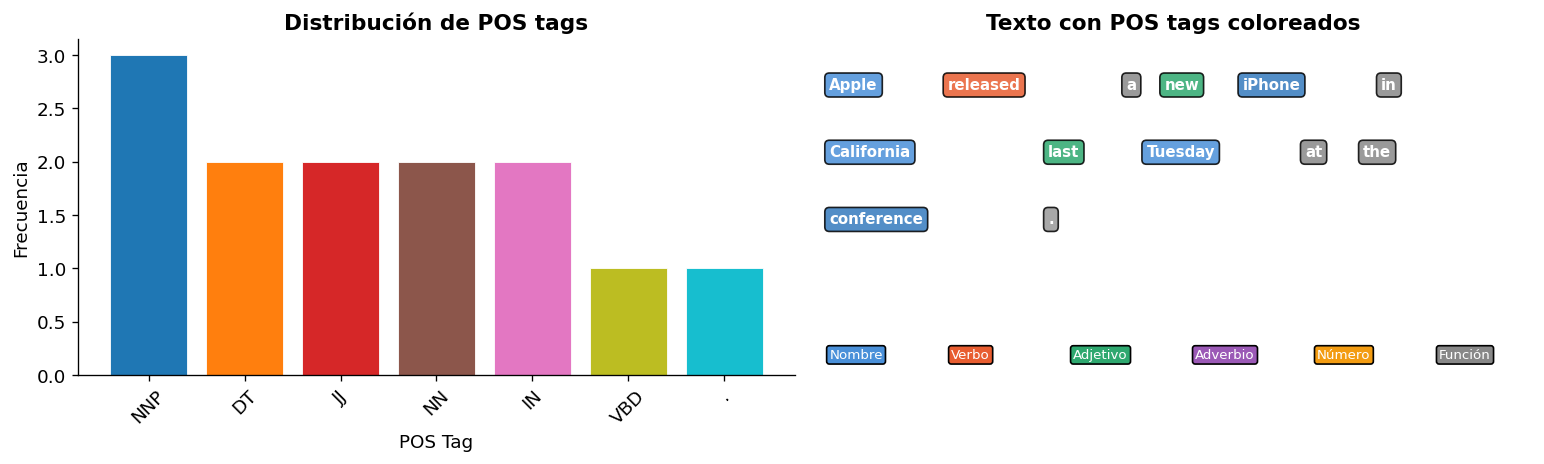

In [19]:
from nltk import pos_tag, ne_chunk
from nltk.chunk import tree2conlltags
nltk.download('averaged_perceptron_tagger_eng')

texto_pos = "Apple released a new iPhone in California last Tuesday at the conference."
tokens_pos = word_tokenize(texto_pos)
pos_tags   = pos_tag(tokens_pos)

print("POS TAGGING:")
print(f"\nTexto: {texto_pos}\n")
print(f"{'Token':<15} {'POS Tag':<10} {'Significado'}")
print("-" * 50)

pos_meaning = {
    'NNP':'Nombre propio', 'NN':'Nombre', 'NNS':'Nombre plural',
    'VBD':'Verbo pasado',  'VBZ':'Verbo 3ª pers', 'JJ':'Adjetivo',
    'IN':'Preposición',    'DT':'Determinante',    'RB':'Adverbio',
    'CD':'Número',         'VBN':'Participio',      'CC':'Conjunción',
}
for token, tag in pos_tags:
    significado = pos_meaning.get(tag, tag)
    print(f"{token:<15} {tag:<10} {significado}")

# Visualizar distribución de POS tags
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

tags_count = Counter([tag for _, tag in pos_tags])
tags_sorted = tags_count.most_common()
tags_n, tags_v = zip(*tags_sorted)
colors_pos = plt.cm.tab10(np.linspace(0, 1, len(tags_n)))

ax = axes[0]
ax.bar(tags_n, tags_v, color=colors_pos, edgecolor='white', linewidth=0.5)
ax.set_xlabel('POS Tag'); ax.set_ylabel('Frecuencia')
ax.set_title('Distribución de POS tags')
ax.tick_params(axis='x', rotation=45)

# Colorear tokens por categoría
ax = axes[1]
ax.set_xlim(0, 1); ax.set_ylim(0, 1); ax.axis('off')
ax.set_title('Texto con POS tags coloreados')

color_map_pos = {
    'NNP':'#4A90D9', 'NN':'#357ABD', 'NNS':'#2E6DA4',
    'VBD':'#E85D30', 'VBZ':'#E85D30', 'VBN':'#E85D30',
    'JJ':'#2EA86F',  'IN':'#888',     'DT':'#888',
    'RB':'#9B59B6',  'CD':'#F39C12',  'CC':'#888',
}

x_offset, y_offset = 0.02, 0.85
for token, tag in pos_tags:
    color = color_map_pos.get(tag, '#999')
    text_obj = ax.text(x_offset, y_offset, token, fontsize=9,
                       color='white', fontweight='bold',
                       bbox=dict(boxstyle='round,pad=0.3',
                                 facecolor=color, alpha=0.85))
    x_offset += len(token)*0.028 + 0.025
    if x_offset > 0.85:
        x_offset = 0.02
        y_offset -= 0.2

# Leyenda
leyenda_items = [
    ('#4A90D9','Nombre'), ('#E85D30','Verbo'),
    ('#2EA86F','Adjetivo'), ('#9B59B6','Adverbio'),
    ('#F39C12','Número'), ('#888','Función'),
]
for i, (color, label) in enumerate(leyenda_items):
    ax.text(0.02 + i*0.17, 0.05, label, fontsize=8, color='white',
            bbox=dict(boxstyle='round,pad=0.2', facecolor=color))

plt.tight_layout()
plt.show()

In [22]:
#EXTRACCIÓN FRASES CLAVE

def extraer_frases_clave(texto, n_top=10):
    """
    Extrae frases clave usando TF-IDF sobre el propio documento.
    Técnica: score cada término por su TF-IDF local.
    """
    # Dividir en oraciones como "documentos"
    oraciones = sent_tokenize(texto)
    if len(oraciones) < 2:
        oraciones = [texto]

    vec = TfidfVectorizer(ngram_range=(1,2), stop_words='english',
                          max_features=100)
    try:
        tfidf_matrix = vec.fit_transform(oraciones)
    except ValueError:
        return []

    # Score de cada término = suma de TF-IDF en todas las oraciones
    scores     = tfidf_matrix.sum(axis=0).A1
    vocab_k    = vec.get_feature_names_out()
    ranked     = sorted(zip(vocab_k, scores), key=lambda x: x[1], reverse=True)
    return ranked[:n_top]

text= """
Machine learning is a subset of artificial intelligence that enables computers
to learn from data without being explicitly programmed. Supervised learning
algorithms learn from labeled training data to make predictions on new data.
Neural networks are powerful machine learning models inspired by the human brain.
Deep learning uses multiple layers of neural networks to learn complex patterns.
Feature engineering and data preprocessing are critical steps in machine learning.
Model evaluation uses metrics like accuracy, precision, recall and F1 score.
Overfitting occurs when a model learns noise in training data and fails to generalize.
Cross validation helps estimate model performance on unseen data reliably.
"""

frases_clave = extraer_frases_clave(text)

print("EXTRACCIÓN DE FRASES CLAVE (TF-IDF):")
print(f"\nTexto analizado ({len(texto_largo.split())} palabras)\n")
print(f"{'Rango':<7} {'Frase clave':<30} {'Score TF-IDF':<15} Barra")
print("-" * 70)
max_score = frases_clave[0][1] if frases_clave else 1
for i, (frase, score) in enumerate(frases_clave, 1):
    barra = "█" * int(score/max_score * 20)
    print(f"  #{i:<4} {frase:<30} {score:.4f}          {barra}")



EXTRACCIÓN DE FRASES CLAVE (TF-IDF):

Texto analizado (103 palabras)

Rango   Frase clave                    Score TF-IDF    Barra
----------------------------------------------------------------------
  #1    data                           0.9435          ████████████████████
  #2    learning                       0.7713          ████████████████
  #3    machine                        0.6212          █████████████
  #4    machine learning               0.6212          █████████████
  #5    model                          0.6117          ████████████
  #6    learn                          0.5582          ███████████
  #7    uses                           0.4516          █████████
  #8    training                       0.4347          █████████
  #9    training data                  0.4347          █████████
  #10   networks                       0.4322          █████████


 8️⃣ Métricas de evaluación en NLP

Las métricas de NLP varían según la tarea. Algunas son
las mismas que en clasificación general, otras son específicas.

| Tarea | Métricas principales |
|---|---|
| Clasificación de texto | Accuracy, F1, Precision, Recall, AUC-ROC |
| NER / Chunking | F1 por entidad (exact match) |
| Extracción de frases clave | Precision@K, Recall@K, F1@K |
| Análisis de sentimiento | Accuracy, MAE (si ordinal) |
| Similitud de textos | Correlación de Pearson/Spearman con juicio humano |

### Métricas específicas de NLP

**Precision@K** — de las K frases extraídas, cuántas son realmente clave

**Recall@K** — de todas las frases clave reales, cuántas están en el top K

**Kappa de Cohen** — acuerdo entre anotadores humanos, descuenta el azar

In [25]:
mejor_pipeline = resultados[mejor]['pipeline']
y_pred_final   = resultados[mejor]['y_pred']

print(f"EVALUACIÓN COMPLETA — {mejor}")
print("=" * 55)
print(classification_report(y_te, y_pred_final,
                             target_names=['Negativa','Positiva']))

# Análisis de errores
print("ANÁLISIS DE ERRORES:")
print("-" * 55)
errores = [(texto, real, pred) for texto, real, pred
           in zip(X_te, y_te, y_pred_final) if real != pred]

if errores:
    for texto, real, pred in errores:
        label_real = "POS" if real == 1 else "NEG"
        label_pred = "POS" if pred == 1 else "NEG"
        print(f"  Real: {label_real} | Pred: {label_pred}")
        print(f"  Texto: {texto}")
        print()
else:
    print("  ✅ Sin errores en el test set")




EVALUACIÓN COMPLETA — Naive Bayes
              precision    recall  f1-score   support

    Negativa       1.00      1.00      1.00         4
    Positiva       1.00      1.00      1.00         4

    accuracy                           1.00         8
   macro avg       1.00      1.00      1.00         8
weighted avg       1.00      1.00      1.00         8

ANÁLISIS DE ERRORES:
-------------------------------------------------------
  ✅ Sin errores en el test set


# Pipeline NLP clásico completo

```python
# 1. PREPROCESAMIENTO
texto = texto.lower()
texto = re.sub(r'[^\w\s]', ' ', texto)
tokens = word_tokenize(texto)
tokens = [t for t in tokens if t not in stopwords]
tokens = [lemmatizer.lemmatize(t) for t in tokens]

# 2. REPRESENTACIÓN NUMÉRICA
vectorizer = TfidfVectorizer(ngram_range=(1,2))
X = vectorizer.fit_transform(corpus)

# 3. SIMILITUD
sim = cosine_similarity(X)

# 4. CLASIFICACIÓN — Pipeline completo
pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(ngram_range=(1,2))),
    ('clf',   LogisticRegression()),
])
pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)

# 5. EVALUACIÓN
print(classification_report(y_test, y_pred))